<a href="https://colab.research.google.com/github/sophieporton/banking77_classification/blob/main/banking77_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BANKING77 Intent Classification

Fine-grained intent detection on 13,083 customer service queries across 77 banking intents.

**Dataset:** [PolyAI BANKING77](https://github.com/PolyAI-LDN/task-specific-datasets)  
**Approach:** TF-IDF + Logistic Regression baseline → DistilBERT fine-tuning

## 1. Setup

In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load Data

In [3]:
dataset = load_dataset("PolyAI/banking77", revision="refs/convert/parquet")
print(dataset)

0000.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [4]:
# Convert to DataFrames
label_names = dataset['train'].features['label'].names
label_name_to_id = {name: i for i, name in enumerate(label_names)}

train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

# Map integer labels to string names
train_df['intent'] = train_df['label'].map(lambda i: label_names[i])
test_df['intent']  = test_df['label'].map(lambda i: label_names[i])

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows | Intents: {len(label_names)}')
train_df.head()

Train: 10,003 rows | Test: 3,080 rows | Intents: 77


,text,label,intent
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


## 3. Exploratory Data Analysis

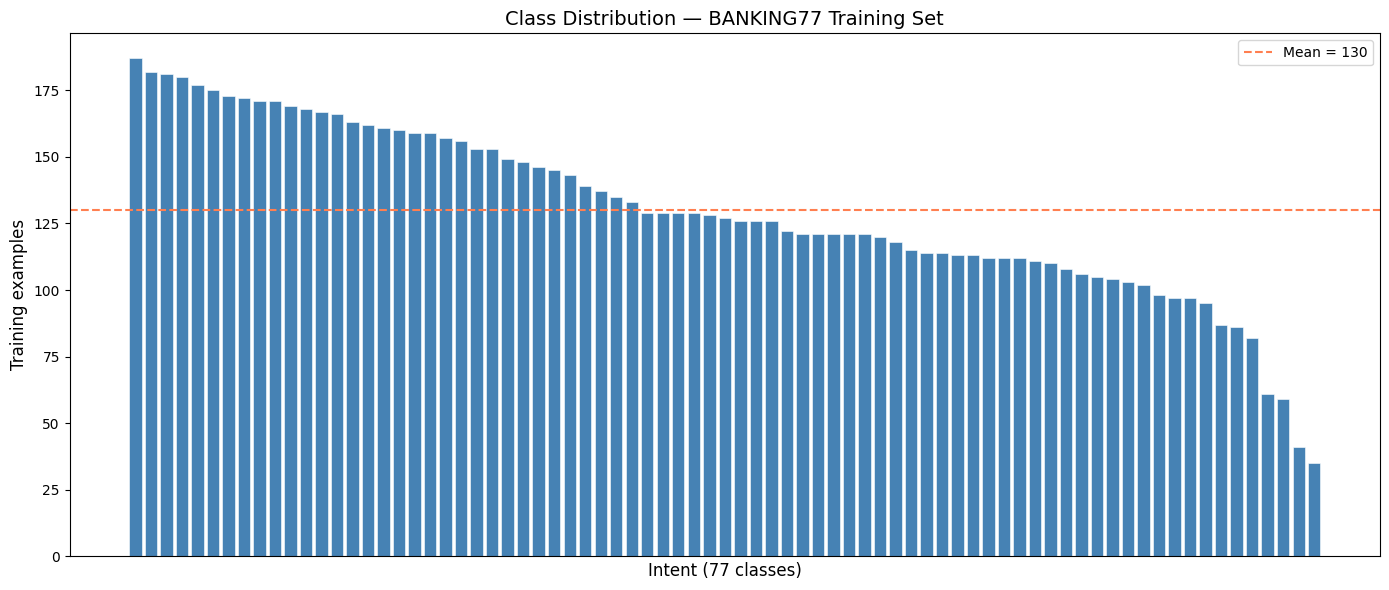

Examples per intent  min=35  max=187  mean=129.9


In [5]:
# --- Class distribution ---
intent_counts = train_df['intent'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(intent_counts)), intent_counts.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xticks([])
ax.set_xlabel('Intent (77 classes)', fontsize=12)
ax.set_ylabel('Training examples', fontsize=12)
ax.set_title('Class Distribution — BANKING77 Training Set', fontsize=14)
ax.axhline(intent_counts.mean(), color='coral', linestyle='--', label=f'Mean = {intent_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Examples per intent  min={intent_counts.min()}  max={intent_counts.max()}  mean={intent_counts.mean():.1f}')

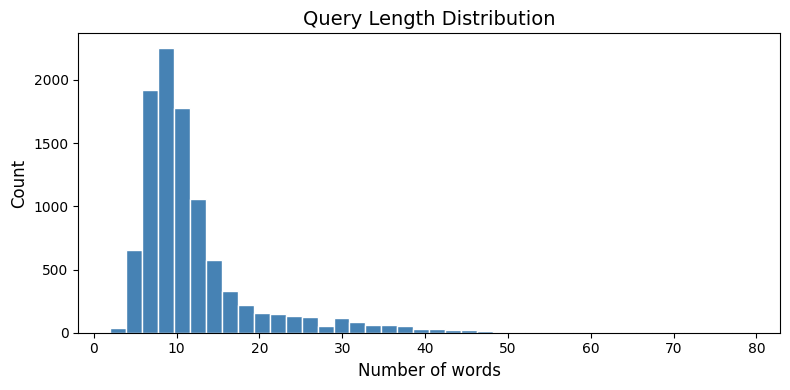

count    10003.0
mean        11.9
std          7.9
min          2.0
25%          7.0
50%         10.0
75%         13.0
max         79.0
Name: n_words, dtype: float64


In [6]:
# --- Query length distribution ---
train_df['n_words'] = train_df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_df['n_words'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of words', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Query Length Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(train_df['n_words'].describe().round(1))

In [7]:
# --- Sample queries per intent ---
sample_intents = ['lost_or_stolen_card', 'exchange_rate', 'top_up_failed', 'verify_my_identity']
for intent in sample_intents:
    samples = train_df.loc[train_df['intent'] == intent, 'text'].sample(2, random_state=SEED).tolist()
    print(f'\n[{intent}]')
    for s in samples:
        print(f'  • {s}')


[lost_or_stolen_card]
  • My wallet was stolen, along with my cards. How do I put a freeze on my cards and order a new one?
  • Has there been any activity on my card today?

[exchange_rate]
  • Where can I get your exchange rates from?
  • how do you get exchange rates

[top_up_failed]
  • Trouble with my top up
  • There has been a red flag on my top up.

[verify_my_identity]
  • What is the identity verification process?
  • If I'm getting my identity verified, what all do I need?


## 4. Baseline: TF-IDF + Logistic Regression

In [8]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)
X_train = tfidf.fit_transform(train_df['text'])
X_test  = tfidf.transform(test_df['text'])

lr = LogisticRegression(max_iter=1000, C=5, random_state=SEED)
lr.fit(X_train, train_df['label'])

y_pred_baseline = lr.predict(X_test)
acc_baseline = accuracy_score(test_df['label'], y_pred_baseline)
f1_baseline  = f1_score(test_df['label'], y_pred_baseline, average='macro')

print(f'Baseline  Accuracy: {acc_baseline:.4f}  Macro-F1: {f1_baseline:.4f}')

Baseline  Accuracy: 0.8903  Macro-F1: 0.8906


## 5. DistilBERT Fine-Tuning

In [9]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

hf_train = dataset['train'].map(tokenize, batched=True)
hf_test  = dataset['test'].map(tokenize, batched=True)

hf_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
hf_test.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [11]:
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
model.to(device);

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='./distilbert-banking77',
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_test,
    compute_metrics=compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.560009,3.229253,0.476948,0.404422
2,1.753008,1.521881,0.760065,0.737566
3,0.913603,0.804956,0.855519,0.846116
4,0.508633,0.522549,0.894805,0.892606
5,0.334592,0.402299,0.907792,0.907504
6,0.236646,0.355537,0.918506,0.918564
7,0.161223,0.321844,0.920130,0.919905
8,0.126530,0.304710,0.923701,0.923631
9,0.094637,0.302803,0.921429,0.921309
10,0.089806,0.298633,0.921104,0.920914


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3130, training_loss=0.922562536111655, metrics={'train_runtime': 1200.8633, 'train_samples_per_second': 83.298, 'train_steps_per_second': 2.606, 'total_flos': 3317109240721920.0, 'train_loss': 0.922562536111655, 'epoch': 10.0})

## 6. Evaluation

In [13]:
results = trainer.evaluate()
print(f"DistilBERT  Accuracy: {results['eval_accuracy']:.4f}  Macro-F1: {results['eval_macro_f1']:.4f}")
print(f"Baseline    Accuracy: {acc_baseline:.4f}  Macro-F1: {f1_baseline:.4f}")

DistilBERT  Accuracy: 0.9237  Macro-F1: 0.9236
Baseline    Accuracy: 0.8903  Macro-F1: 0.8906


In [14]:
# Full classification report
preds_output = trainer.predict(hf_test)
y_pred_bert  = np.argmax(preds_output.predictions, axis=-1)
y_true       = test_df['label'].values

print(classification_report(y_true, y_pred_bert, target_names=label_names))

                                                  precision    recall  f1-score   support

                                activate_my_card       1.00      0.97      0.99        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       1.00      0.97      0.99        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.77      0.75      0.76        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.93      0.95        40
                         beneficiary_not_allowed       0.90      0.88      0.89        40
                                 cancel_transfer       0.97      0.97      0.97        40
                            card_about_to_expire       0.98      1.00      0.99        40
         

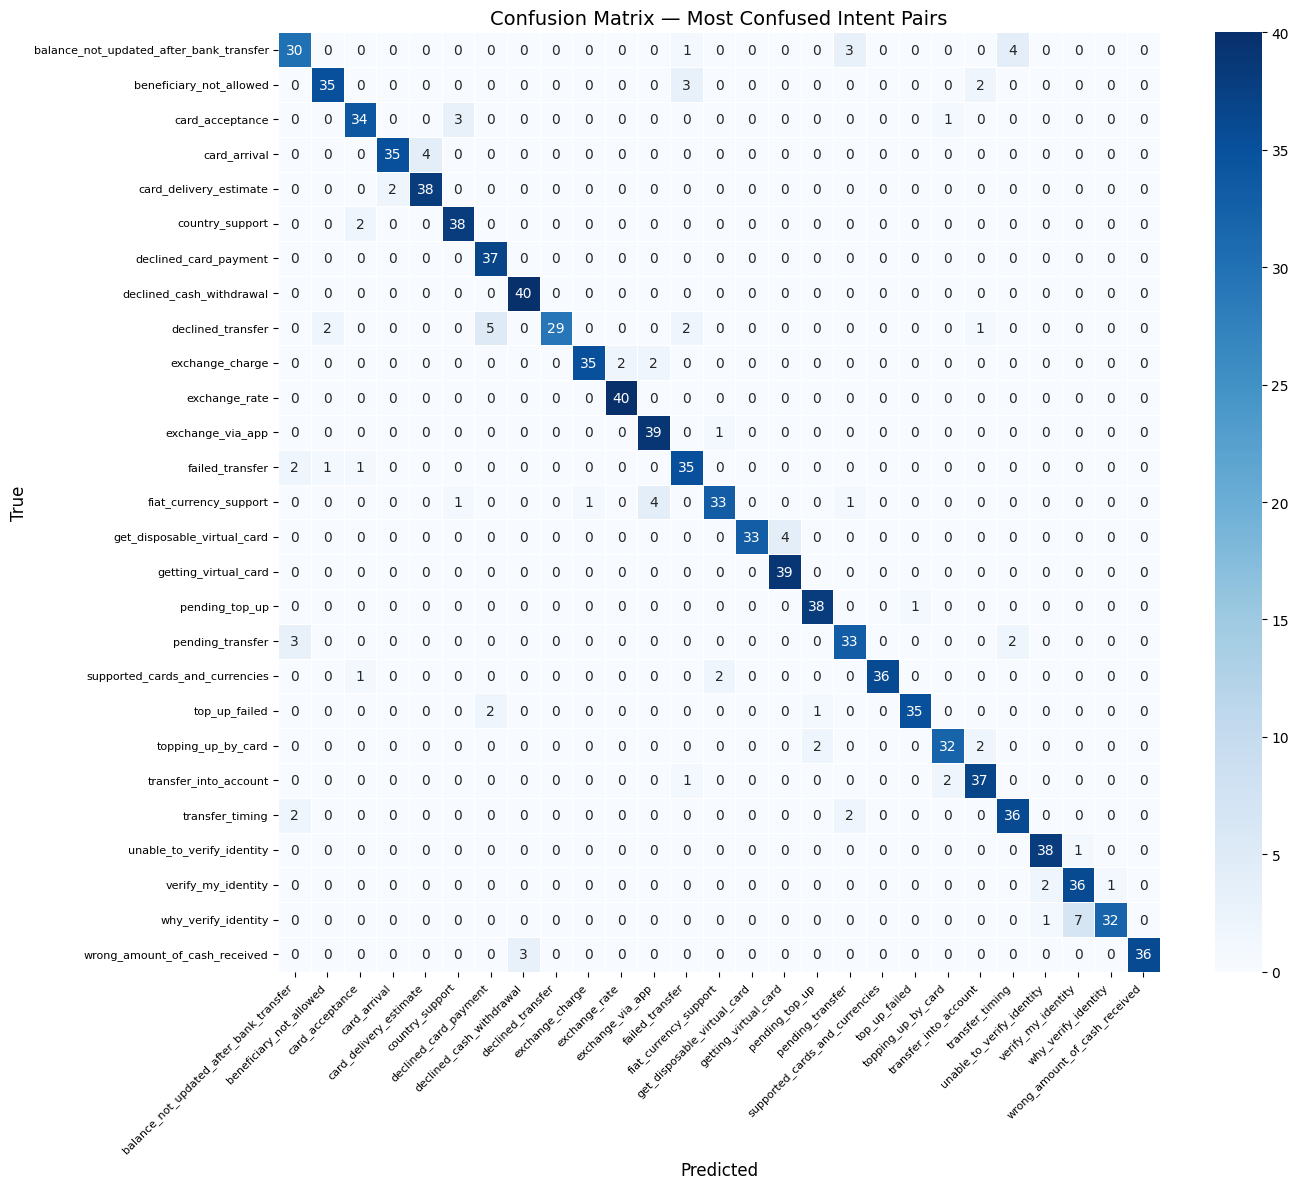

In [15]:
# Confusion matrix — top 20 most confused intent pairs
cm = confusion_matrix(y_true, y_pred_bert)

# Zero out diagonal (correct predictions), find the worst pairs
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

top_n = 20
flat_idx = np.argsort(cm_off.ravel())[::-1][:top_n]
rows, cols = np.unravel_index(flat_idx, cm_off.shape)

confused_labels = sorted(set(rows.tolist() + cols.tolist()))
sub_cm = cm[np.ix_(confused_labels, confused_labels)]
sub_names = [label_names[i] for i in confused_labels]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sub_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sub_names, yticklabels=sub_names, ax=ax,
    linewidths=0.5,
)
ax.set_title('Confusion Matrix — Most Confused Intent Pairs', fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Inference Demo

In [16]:
def predict_intent(query: str) -> str:
    """Return the predicted banking intent for a customer query."""
    inputs = tokenizer(query, return_tensors='pt', truncation=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_id = logits.argmax(-1).item()
    confidence = torch.softmax(logits, dim=-1)[0, pred_id].item()
    return label_names[pred_id], confidence


example_queries = [
    "I lost my card, what should I do?",
    "Why hasn't my top-up appeared yet?",
    "What's the exchange rate for USD to EUR?",
    "My card payment was charged twice",
    "How do I change my PIN?",
    "I want to cancel a transfer I just made",
    "Can I use my card in Japan?",
    "How long does it take to get a physical card?",
]

print(f'{'Query':<55} {'Predicted Intent':<45} Confidence')
print('-' * 110)
for q in example_queries:
    intent, conf = predict_intent(q)
    print(f'{q:<55} {intent:<45} {conf:.2%}')

Query                                                   Predicted Intent                              Confidence
--------------------------------------------------------------------------------------------------------------
I lost my card, what should I do?                       lost_or_stolen_card                           95.59%
Why hasn't my top-up appeared yet?                      pending_top_up                                97.95%
What's the exchange rate for USD to EUR?                exchange_rate                                 75.84%
My card payment was charged twice                       transaction_charged_twice                     98.74%
How do I change my PIN?                                 change_pin                                    98.09%
I want to cancel a transfer I just made                 cancel_transfer                               98.04%
Can I use my card in Japan?                             country_support                               76.27%
How long does

In [17]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)

# Run on full test set
y_pred_zs_names = []
for query in tqdm(test_df['text'].tolist(), desc="Classifying with BART"):
    result = classifier(query, candidate_labels=label_names, multi_label=False)
    y_pred_zs_names.append(result['labels'][0].lower().strip())

# Convert to integer labels
y_pred_zs = [label_name_to_id.get(name, -1) for name in y_pred_zs_names]
invalid = sum(1 for p in y_pred_zs if p == -1)
print(f"Invalid predictions: {invalid}/{len(y_pred_zs)}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Classifying with BART: 100%|██████████| 3080/3080 [1:17:16<00:00,  1.51s/it]

Invalid predictions: 22/3080


In [18]:
valid_mask   = [p != -1 for p in y_pred_zs]
y_true_valid = [y_true[i] for i, v in enumerate(valid_mask) if v]
y_pred_valid = [p for p in y_pred_zs if p != -1]

acc_zs   = accuracy_score(y_true_valid, y_pred_valid)
f1_zs    = f1_score(y_true_valid, y_pred_valid, average='macro')
bert_acc = accuracy_score(y_true, y_pred_bert)
bert_f1  = f1_score(y_true, y_pred_bert, average='macro')

print("=" * 60)
print(f"{'Method':<35} {'Accuracy':>10} {'Macro-F1':>10}")
print("-" * 60)
print(f"{'TF-IDF + Logistic Regression':<35} {acc_baseline:>10.4f} {f1_baseline:>10.4f}")
print(f"{'DistilBERT (fine-tuned)':<35} {bert_acc:>10.4f} {bert_f1:>10.4f}")
print(f"{'BART-large (zero-shot)':<35} {acc_zs:>10.4f} {f1_zs:>10.4f}")
print("=" * 60)


Method                                Accuracy   Macro-F1
------------------------------------------------------------
TF-IDF + Logistic Regression            0.8903     0.8906
DistilBERT (fine-tuned)                 0.9237     0.9236
BART-large (zero-shot)                  0.3545     0.3452
